<a href="https://colab.research.google.com/github/Cyberpunk-San/ML-practice/blob/Classification-Metrics/Classification_Metrics_Scratch.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Classification Metrics - Scratch

In [3]:
import numpy as np

class ClassificationEvaluator:
    def __init__(self, y_true, y_pred):
        self.y_true = np.array(y_true)
        self.y_pred = np.array(y_pred)
        self.classes = np.unique(self.y_true)
        self.matrix = self._compute_confusion_matrix()

    def _compute_confusion_matrix(self):
        n = len(self.classes)
        matrix = np.zeros((n, n), dtype=int)
        # Rows = Actual, Columns = Predicted
        for actual, predicted in zip(self.y_true, self.y_pred):
            matrix[actual, predicted] += 1
        return matrix

    def get_metrics_per_class(self):
        metrics = {}
        for i, cls in enumerate(self.classes):
            tp = self.matrix[i, i]
            fp = self.matrix[:, i].sum() - tp
            fn = self.matrix[i, :].sum() - tp

            precision = tp / (tp + fp) if (tp + fp) > 0 else 0
            recall = tp / (tp + fn) if (tp + fn) > 0 else 0
            f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

            metrics[cls] = {"precision": precision, "recall": recall, "f1": f1}
        return metrics

    def macro_f1(self):
        # Average F1 score across all classes
        m = self.get_metrics_per_class()
        return np.mean([val["f1"] for val in m.values()])

CLass Model

In [4]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train a simple classifier (e.g., RandomForest) to get predictions
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_probs = model.predict_proba(X_test)

print("y_test and y_pred variables have been defined.")

y_test and y_pred variables have been defined.


Data Processing

In [5]:
# Assuming y_test and y_pred are from your previous Iris model runs
evaluator = ClassificationEvaluator(y_test, y_pred)
print("Confusion Matrix (Rows: Actual, Cols: Pred):")
print(evaluator.matrix)

print("\nPer-Class Metrics:")
for cls, m in evaluator.get_metrics_per_class().items():
    print(f"Class {cls}: Precision={m['precision']:.2f}, Recall={m['recall']:.2f}, F1={m['f1']:.2f}")

print(f"\nOverall Macro F1-Score: {evaluator.macro_f1():.4f}")

Confusion Matrix (Rows: Actual, Cols: Pred):
[[19  0  0]
 [ 0 13  0]
 [ 0  0 13]]

Per-Class Metrics:
Class 0: Precision=1.00, Recall=1.00, F1=1.00
Class 1: Precision=1.00, Recall=1.00, F1=1.00
Class 2: Precision=1.00, Recall=1.00, F1=1.00

Overall Macro F1-Score: 1.0000


Execution

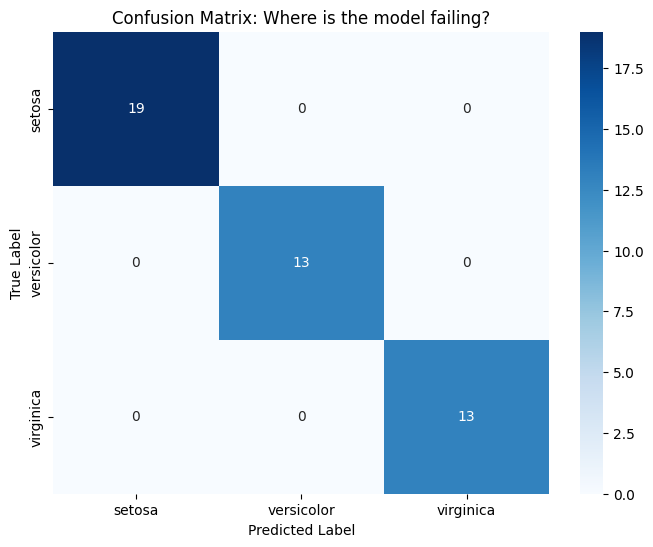

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(evaluator.matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names, yticklabels=iris.target_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix: Where is the model failing?')
plt.show()

Graph

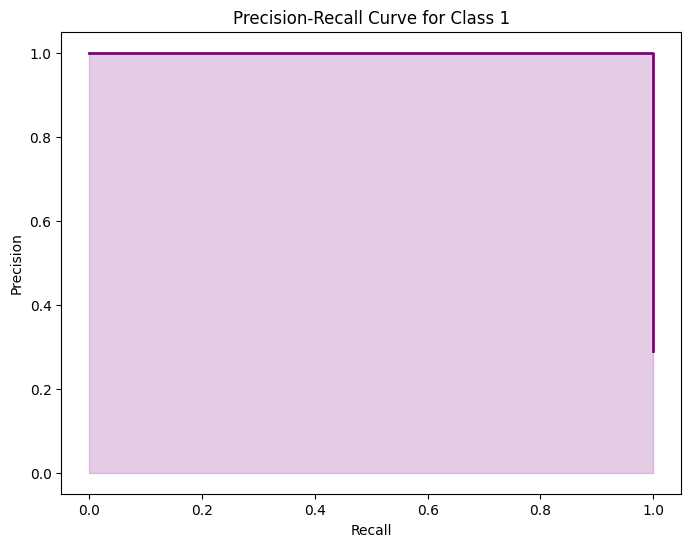

In [8]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# For binary case (e.g., Is the drone crashing?)
# Fix: Binarize y_test for the target class (e.g., class 1)
# Let's calculate for class 1
class_id = 1
y_test_binary = (y_test == class_id).astype(int)
precisions, recalls, thresholds = precision_recall_curve(y_test_binary, y_probs[:, class_id])

plt.figure(figsize=(8, 6))
plt.plot(recalls, precisions, color='purple', lw=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title(f'Precision-Recall Curve for Class {class_id}')
plt.fill_between(recalls, precisions, alpha=0.2, color='purple')
plt.show()

The Confusion Matrix acts as our map, showing us exactly which classes are being swapped (e.g., confusing Iris-Versicolor with Iris-Virginica).

Precision protects us from "False Alarms," while Recall ensures we don't miss actual events.

F1-Score gives us a single number to optimize, which is vital for your competitive programming challenges or when you're tuning hyperparameters for XGBoost.